In [1]:
from data_handling_raw import BorderDataset, prepare_datasets_for_configs, prepare_dataset
from model_raw import BorderDetector
from utils_raw import EarlyStopping, TrainingMetrics, evaluate_model, save_checkpoint
from training_raw import train_with_cross_validation

import os
import json
from datetime import datetime
import traceback

import matplotlib.pyplot as plt
import numpy as np
import matplotlib.lines as mlines
from matplotlib.legend_handler import HandlerLine2D

import onnxruntime as ort
import cv2
from glob import glob
import time

import matplotlib.pyplot as plt
import pandas as pd

In [4]:
from itertools import product

# Define base configurations
base_configs = [
    {"name": "tiny_deep", "conv_channels": [2, 4, 4], "fc_size": 32, "dropout_rate": 0.1, "learning_rate": 0.001, "weight_decay": 0.0001},
    {"name": "micro_uniform", "conv_channels": [4, 4, 4], "fc_size": 32, "dropout_rate": 0.2, "learning_rate": 0.001, "weight_decay": 0.0001},
    {"name": "small_pyramid", "conv_channels": [4, 6, 8], "fc_size": 64, "dropout_rate": 0.15, "learning_rate": 0.001, "weight_decay": 0.0001},
    {"name": "tiny_efficient", "conv_channels": [2, 4, 4], "fc_size": 16, "dropout_rate": 0.1, "learning_rate": 0.001, "weight_decay": 0.0001},
    {"name": "efficient_micro", "conv_channels": [2, 2, 2], "fc_size": 16, "dropout_rate": 0.1, "learning_rate": 0.001, "weight_decay": 0.0001},
    {"name": "efficient_nano", "conv_channels": [1, 2, 2], "fc_size": 8, "dropout_rate": 0.05, "learning_rate": 0.002, "weight_decay": 0.00001}
]

# Common parameters
common_config = {
    "grad_clip": 0.5,
    "num_epochs": 100,
    "num_rotations": 2,
    "accumulation_steps": 8,
    "patience": 8,
    "augment_brightness_contrast": True,
    "batch_size": 1,
    "downscale_factor": 2,
    "use_efficient": False,
}

def get_input_size(downscale_factor):
    return 120 // downscale_factor

# Generate permutations
variants = list(product(
    [False, True],  # use_efficient
    [2, 4],         # downscale_factor
    [False, True]   # augmentations
))

configs = []
for base in base_configs:
    for use_efficient, downscale_factor, augment in variants:
        config = base.copy()
        config.update(common_config)
        config["use_efficient"] = use_efficient
        config["downscale_factor"] = downscale_factor
        config["num_rotations"] = 2 if augment else 0
        config["augment_brightness_contrast"] = augment
        configs.append(config)

# Print the total number of configurations
print(f"Number of configs: {len(configs)}")


Number of configs: 48


In [ ]:
def prepare_datasets_for_configs(configs, data_dir, debug=False):
    # Create a dictionary to store unique dataset configurations
    dataset_configs = {}
    
    for config in configs:
        # Create a key based on dataset-specific parameters
        dataset_key = (
            config['num_rotations'],
            config['augment_brightness_contrast'],
            config.get('downscale_factor', 2)
        )
        
        # Only prepare dataset if we haven't seen these parameters before
        if dataset_key not in dataset_configs:
            print(f"\nPreparing dataset with parameters:")
            print(f"- num_rotations: {config['num_rotations']}")
            print(f"- augment_brightness_contrast: {config['augment_brightness_contrast']}")
            print(f"- downscale_factor: {config.get('downscale_factor', 1)}")
            
            images, labels, sources = prepare_dataset(
                data_dir,
                num_rotations=config['num_rotations'],
                augment_brightness_contrast=config['augment_brightness_contrast'],
                downscale_factor=config.get('downscale_factor', 1),
                debug=debug
            )
            
            dataset_configs[dataset_key] = (images, labels, sources)
    
    return dataset_configs

def run_experiment_with_cv(config, experiment_name, main_output_dir, dataset_tuple=None, n_folds=5):
    """
    Run an experiment with cross-validation.
    
    Args:
        config: Configuration dictionary
        experiment_name: Name of the experiment
        main_output_dir: Main output directory
        dataset_tuple: Tuple containing (images, labels, sources)
        n_folds: Number of folds for cross-validation
    
    Returns:
        Dictionary containing experiment results
    """
    try:
        print(f"\nStarting experiment with {n_folds}-fold cross-validation: {experiment_name}")
        
        # Create experiment directory
        experiment_dir = os.path.join(main_output_dir, experiment_name)
        os.makedirs(experiment_dir, exist_ok=True)
        
        # Store the configuration
        with open(os.path.join(experiment_dir, 'config.json'), 'w') as f:
            json.dump(config, f, indent=2)
        
        # Add cross-validation to config
        cv_config = config.copy()
        cv_config['n_folds'] = n_folds
        
        # Run cross-validation
        cv_results, cv_output_dir = train_with_cross_validation(cv_config, dataset_tuple, n_folds)
        
        # Analyze cross-validation results
        cv_analysis = analyze_cv_results(cv_results, experiment_dir)
        
        return {
            'status': 'success',
            'experiment_name': experiment_name,
            'output_dir': cv_output_dir,
            'cv_analysis': cv_analysis,
            'quantized': config.get('quantize', False)
        }
        
    except Exception as e:
        print(f"Error in experiment {experiment_name} with cross-validation: {str(e)}")
        print("\nFull traceback:")
        print(traceback.format_exc())
        # Try again with a smaller learning rate if we haven't already
        if 'rerun' not in config and 'learning_rate' in config:
            config['learning_rate'] = config['learning_rate'] / 3
            config['rerun'] = True
            print(f"Retrying with smaller learning rate: {config['learning_rate']}")
            return run_experiment_with_cv(config, experiment_name, main_output_dir, dataset_tuple, n_folds)
        return {
            'status': 'failed',
            'experiment_name': experiment_name,
            'error': str(e)
        }

def analyze_cv_results(cv_results, output_dir):
    """
    Analyze the results of cross-validation.
    
    Args:
        cv_results: Dictionary containing cross-validation results
        output_dir: Directory to save analysis results
    
    Returns:
        Dictionary containing analysis results
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.metrics import roc_curve, auc
    
    # Extract metrics
    auc_scores = cv_results['val_auc_scores']
    accuracies = cv_results['val_accuracies']
    f1_scores = cv_results['val_f1_scores']
    fold_metrics = cv_results['fold_metrics']
    
    # Calculate statistics
    analysis = {
        'auc': {
            'mean': float(np.mean(auc_scores)),
            'std': float(np.std(auc_scores)),
            'min': float(np.min(auc_scores)),
            'max': float(np.max(auc_scores)),
            'values': [float(x) for x in auc_scores]
        },
        'accuracy': {
            'mean': float(np.mean(accuracies)),
            'std': float(np.std(accuracies)),
            'min': float(np.min(accuracies)),
            'max': float(np.max(accuracies)),
            'values': [float(x) for x in accuracies]
        },
        'f1': {
            'mean': float(np.mean(f1_scores)),
            'std': float(np.std(f1_scores)),
            'min': float(np.min(f1_scores)),
            'max': float(np.max(f1_scores)),
            'values': [float(x) for x in f1_scores]
        },
        'fold_metrics': fold_metrics
    }
    
    # Create visualizations
    plt.figure(figsize=(15, 10))
    
    # AUC scores across folds
    plt.subplot(2, 2, 1)
    plt.bar(range(1, len(auc_scores) + 1), auc_scores)
    plt.axhline(y=np.mean(auc_scores), color='r', linestyle='--', label=f'Mean: {np.mean(auc_scores):.4f}')
    plt.title('AUC Scores Across Folds')
    plt.xlabel('Fold')
    plt.ylabel('AUC Score')
    plt.ylim(0.5, 1.05)  # AUC is typically between 0.5 and 1
    plt.legend()
    
    # Accuracy across folds
    plt.subplot(2, 2, 2)
    plt.bar(range(1, len(accuracies) + 1), accuracies)
    plt.axhline(y=np.mean(accuracies), color='r', linestyle='--', label=f'Mean: {np.mean(accuracies):.4f}')
    plt.title('Accuracy Across Folds')
    plt.xlabel('Fold')
    plt.ylabel('Accuracy')
    plt.ylim(0.5, 1.05)
    plt.legend()
    
    # F1 scores across folds
    plt.subplot(2, 2, 3)
    plt.bar(range(1, len(f1_scores) + 1), f1_scores)
    plt.axhline(y=np.mean(f1_scores), color='r', linestyle='--', label=f'Mean: {np.mean(f1_scores):.4f}')
    plt.title('F1 Scores Across Folds')
    plt.xlabel('Fold')
    plt.ylabel('F1 Score')
    plt.ylim(0, 1.05)
    plt.legend()
    
    # Metric comparison
    plt.subplot(2, 2, 4)
    metrics = ['AUC', 'Accuracy', 'F1']
    means = [np.mean(auc_scores), np.mean(accuracies), np.mean(f1_scores)]
    stds = [np.std(auc_scores), np.std(accuracies), np.std(f1_scores)]
    
    plt.bar(metrics, means, yerr=stds, capsize=10)
    plt.title('Metric Comparison')
    plt.ylabel('Score')
    plt.ylim(0.5, 1.05)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'cv_analysis.png'))
    plt.close()
    
    # Save analysis results
    analysis_path = os.path.join(output_dir, 'cv_analysis.json')
    with open(analysis_path, 'w') as f:
        json.dump(analysis, f, indent=2)
    
    return analysis

def compare_cv_experiments(results, output_dir):
    """
    Compare results from multiple cross-validation experiments.
    
    Args:
        results: List of experiment results
        output_dir: Directory to save comparison results
    
    Returns:
        Dictionary containing comparison results
    """

    
    # Extract successful experiments with CV results
    successful_cv_experiments = [r for r in results if r['status'] == 'success' and 'cv_analysis' in r]
    
    if not successful_cv_experiments:
        print("No successful cross-validation experiments to compare.")
        return None
    
    # Create comparison data
    comparison = {
        'experiment_names': [],
        'auc_mean': [],
        'auc_std': [],
        'accuracy_mean': [],
        'accuracy_std': [],
        'f1_mean': [],
        'f1_std': []
    }
    
    for exp in successful_cv_experiments:
        comparison['experiment_names'].append(exp['experiment_name'])
        comparison['auc_mean'].append(exp['cv_analysis']['auc']['mean'])
        comparison['auc_std'].append(exp['cv_analysis']['auc']['std'])
        comparison['accuracy_mean'].append(exp['cv_analysis']['accuracy']['mean'])
        comparison['accuracy_std'].append(exp['cv_analysis']['accuracy']['std'])
        comparison['f1_mean'].append(exp['cv_analysis']['f1']['mean'])
        comparison['f1_std'].append(exp['cv_analysis']['f1']['std'])
    
    # Create DataFrame for easier analysis
    df = pd.DataFrame({
        'Experiment': comparison['experiment_names'],
        'AUC Mean': comparison['auc_mean'],
        'AUC Std': comparison['auc_std'],
        'Accuracy Mean': comparison['accuracy_mean'],
        'Accuracy Std': comparison['accuracy_std'],
        'F1 Mean': comparison['f1_mean'],
        'F1 Std': comparison['f1_std']
    })
    
    # Create visualizations
    plt.figure(figsize=(20, 12))
    
    # AUC comparison
    plt.subplot(2, 2, 1)
    plt.bar(comparison['experiment_names'], comparison['auc_mean'], 
            yerr=comparison['auc_std'], capsize=10)
    plt.title('AUC Comparison Across Experiments')
    plt.ylabel('AUC Score')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0.5, 1.05)
    plt.grid(axis='y', alpha=0.3)
    
    # Accuracy comparison
    plt.subplot(2, 2, 2)
    plt.bar(comparison['experiment_names'], comparison['accuracy_mean'], 
            yerr=comparison['accuracy_std'], capsize=10)
    plt.title('Accuracy Comparison Across Experiments')
    plt.ylabel('Accuracy')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0.5, 1.05)
    plt.grid(axis='y', alpha=0.3)
    
    # F1 comparison
    plt.subplot(2, 2, 3)
    plt.bar(comparison['experiment_names'], comparison['f1_mean'], 
            yerr=comparison['f1_std'], capsize=10)
    plt.title('F1 Score Comparison Across Experiments')
    plt.ylabel('F1 Score')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0.5, 1.05)
    plt.grid(axis='y', alpha=0.3)
    
    # Combined metrics
    plt.subplot(2, 2, 4)
    x = np.arange(len(comparison['experiment_names']))
    width = 0.25
    
    plt.bar(x - width, comparison['auc_mean'], width, label='AUC', 
            yerr=comparison['auc_std'], capsize=5)
    plt.bar(x, comparison['accuracy_mean'], width, label='Accuracy', 
            yerr=comparison['accuracy_std'], capsize=5)
    plt.bar(x + width, comparison['f1_mean'], width, label='F1', 
            yerr=comparison['f1_std'], capsize=5)
    
    plt.title('Combined Metrics Comparison')
    plt.ylabel('Score')
    plt.xticks(x, comparison['experiment_names'], rotation=45, ha='right')
    plt.ylim(0.5, 1.05)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'cv_comparison.png'))
    plt.close()
    
    # Save comparison results
    comparison_path = os.path.join(output_dir, 'cv_comparison.json')
    with open(comparison_path, 'w') as f:
        json.dump(comparison, f, indent=2)
    
    # Save DataFrame as CSV
    df.to_csv(os.path.join(output_dir, 'cv_comparison.csv'), index=False)
    
    # Find the best experiment
    best_exp_idx = np.argmax(comparison['auc_mean'])
    best_experiment = {
        'name': comparison['experiment_names'][best_exp_idx],
        'auc_mean': comparison['auc_mean'][best_exp_idx],
        'auc_std': comparison['auc_std'][best_exp_idx],
        'accuracy_mean': comparison['accuracy_mean'][best_exp_idx],
        'accuracy_std': comparison['accuracy_std'][best_exp_idx],
        'f1_mean': comparison['f1_mean'][best_exp_idx],
        'f1_std': comparison['f1_std'][best_exp_idx]
    }
    
    return {
        'comparison': comparison,
        'best_experiment': best_experiment,
        'dataframe': df.to_dict('records')
    }

# Modified main code to incorporate cross-validation
def main_with_cv(configs, n_folds=5, debug=False):
    # Create timestamp at the start
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    main_output_dir = f'experiments_cv/experiment_{timestamp}'
    os.makedirs(main_output_dir, exist_ok=True)

    # Prepare all unique datasets first
    data_dir = 'test_verified_images_raw' if configs[0].get('test_mode', False) else 'verified_images_raw'
    dataset_configs = prepare_datasets_for_configs(configs, data_dir, debug=debug)

    # Run all experiments with cross-validation and collect results
    results = []
    for config in configs:
        experiment_name = config['name']
        print(f"\nRunning experiment with {n_folds}-fold cross-validation: {experiment_name}")
        
        # Get the appropriate dataset based on config parameters
        dataset_key = (
            config['num_rotations'],
            config['augment_brightness_contrast'],
            config.get('downscale_factor', 1)
        )
        dataset_tuple = dataset_configs[dataset_key]
        
        # Run experiment with cross-validation
        result = run_experiment_with_cv(config, experiment_name, main_output_dir, dataset_tuple, n_folds)
        
        result['experiment_name'] = experiment_name
        result['config'] = config
        results.append(result)
        
        # Save intermediate results summary
        summary = {
            'timestamp': timestamp,
            'results': results
        }
        with open(os.path.join(main_output_dir, 'experiments_summary.json'), 'w') as f:
            json.dump(summary, f, indent=2)

    # Print final summary
    print("\n" + "="*50)
    print("Cross-Validation Experiments Summary:")
    print("="*50)

    successful_experiments = [r for r in results if r['status'] == 'success']
    failed_experiments = [r for r in results if r['status'] == 'failed']

    print(f"\nTotal experiments: {len(results)}")
    print(f"Successful experiments: {len(successful_experiments)}")
    print(f"Failed experiments: {len(failed_experiments)}")

    if successful_experiments:
        print("\nSuccessful experiments results:")
        for result in successful_experiments:
            print(f"\nExperiment: {result['experiment_name']}")
            if 'cv_analysis' in result:
                print(f"Mean AUC: {result['cv_analysis']['auc']['mean']:.4f} ± {result['cv_analysis']['auc']['std']:.4f}")
                print(f"Mean Accuracy: {result['cv_analysis']['accuracy']['mean']:.2f}% ± {result['cv_analysis']['accuracy']['std']:.2f}%")
            print(f"Output directory: {result['output_dir']}")

    if failed_experiments:
        print("\nFailed experiments:")
        for result in failed_experiments:
            print(f"\nExperiment: {result['experiment_name']}")
            print(f"Error: {result['error']}")

    # Compare all successful cross-validation experiments
    if len(successful_experiments) > 1:
        print("\nComparing cross-validation results across experiments...")
        comparison = compare_cv_experiments(results, main_output_dir)
        
        if comparison:
            best_exp = comparison['best_experiment']
            print(f"\nBest experiment: {best_exp['name']}")
            print(f"Mean AUC: {best_exp['auc_mean']:.4f} ± {best_exp['auc_std']:.4f}")
            print(f"Mean Accuracy: {best_exp['accuracy_mean']:.2f}% ± {best_exp['accuracy_std']:.2f}%")
            print(f"Mean F1: {best_exp['f1_mean']:.4f} ± {best_exp['f1_std']:.4f}")

    # Save final summary
    final_summary = {
        'timestamp': timestamp,
        'total_experiments': len(results),
        'successful_experiments': len(successful_experiments),
        'failed_experiments': len(failed_experiments),
        'results': results
    }

    # Add best model info if we have a comparison
    if len(successful_experiments) > 1 and 'comparison' in locals():
        final_summary['best_experiment'] = comparison['best_experiment']

    # Save final summary
    with open(os.path.join(main_output_dir, 'final_summary.json'), 'w') as f:
        json.dump(final_summary, f, indent=2)
    
    return main_output_dir, results


    
# Run with cross-validation
output_dir, results = main_with_cv(configs, n_folds=5, debug=False)



Preparing dataset with parameters:
- num_rotations: 0
- augment_brightness_contrast: False
- downscale_factor: 2
Loading and preprocessing dataset...


Processing boundaries:   0%|          | 0/216 [00:00<?, ?it/s]

Processing unlabeled: 100%|██████████| 367/367 [00:10<00:00, 34.96it/s]


Label distribution: {0: 668, 1: 216}

Preparing dataset with parameters:
- num_rotations: 2
- augment_brightness_contrast: True
- downscale_factor: 2
Loading and preprocessing dataset...


Processing unlabeled: 100%|██████████| 367/367 [00:10<00:00, 34.95it/s]


...


Training fold 5/5


Fold 5 Epochs:  53%|█████▎    | 53/100 [02:14<01:58,  2.53s/it]

Early stopping triggered at epoch 54
Fold 5 - Best model at epoch 48 with AUC: 0.9495



/home/daniel/Documents/GitHub/paparazzi/BottomCamDetector/training_raw.py:502: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path)



Cross-validation results (5 folds):
Average AUC: 0.9083 ± 0.0278
Average Accuracy: 84.8758 ± 3.7443
Average F1 Score: 0.8495 ± 0.0499
Summary saved to results_raw/cv_training_20250318_224726/cv_summary.json

Cross-Validation Experiments Summary:

Total experiments: 48
Successful experiments: 46
Failed experiments: 2

Successful experiments results:

Experiment: tiny_deep
Mean AUC: 0.9285 ± 0.0579
Mean Accuracy: 87.09% ± 9.20%
Output directory: results_raw/cv_training_20250318_181305

Experiment: tiny_deep
Mean AUC: 0.9681 ± 0.0143
Mean Accuracy: 90.42% ± 2.71%
Output directory: results_raw/cv_training_20250318_181540

Experiment: tiny_deep
Mean AUC: 0.9641 ± 0.0130
Mean Accuracy: 90.50% ± 3.41%
Output directory: results_raw/cv_training_20250318_182022

Experiment: tiny_deep
Mean AUC: 0.9454 ± 0.0212
Mean Accuracy: 86.70% ± 2.20%
Output directory: results_raw/cv_training_20250318_182305

Experiment: tiny_deep
Mean AUC: 0.9052 ± 0.0342
Mean Accuracy: 82.13% ± 5.26%
Output directory: res

In [6]:
import json
import os
import shutil
import numpy as np
from pathlib import Path

def load_summary(folder):
    summary_path = os.path.join(folder, 'cv_summary.json')
    if not os.path.exists(summary_path):
        return None
    with open(summary_path, 'r') as f:
        return json.load(f)

def evaluate_model(summary):
    # Thresholds for filtering
    MIN_AUC = 0.90
    MAX_AUC_STD = 0.04
    MAX_ACC_STD = 5.0
    
    if (summary['avg_auc'] < MIN_AUC or 
        summary['std_auc'] > MAX_AUC_STD or 
        summary['std_acc'] > MAX_ACC_STD):
        return False, None
    
    # Find most representative fold (closest to mean AUC)
    fold_aucs = [fold['val_auc'] for fold in summary['fold_results']]
    mean_auc = summary['avg_auc']
    best_fold_idx = int(np.argmin([abs(auc - mean_auc) for auc in fold_aucs]))
    
    return True, best_fold_idx + 1  # +1 because fold numbers start at 1

def process_results(raw_results_dir, output_dir):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    selected_models = []
    model_counter = 1
    
    # Process each experiment folder
    for folder in sorted(os.listdir(raw_results_dir)):
        folder_path = os.path.join(raw_results_dir, folder)
        if not os.path.isdir(folder_path):
            continue
        print(f"Processing folder: {folder}")
        try:
            summary = load_summary(folder_path)
        except Exception as e:
            print(f"Error loading summary for {folder}: {str(e)}")
            continue
        if not summary:
            continue
            
        is_good_model, best_fold = evaluate_model(summary)
        if not is_good_model:
            continue
            
        # Check if the model file exists
        fold_dir = os.path.join(folder_path, f'fold_{best_fold}')
        model_file = os.path.join(fold_dir, f'best_model_fold_{best_fold}.onnx')
        config_file = os.path.join(folder_path, 'cv_config.json')
        
        if not (os.path.exists(model_file) and os.path.exists(config_file)):
            print(f"Files missing for {folder}")
            continue
            
        # Copy files with new names
        new_model_name = f'model_{model_counter}.onnx'
        new_config_name = f'config_{model_counter}.json'
        
        shutil.copy2(model_file, os.path.join(output_dir, new_model_name))
        shutil.copy2(config_file, os.path.join(output_dir, new_config_name))
        
        # Store information about selected model
        selected_models.append({
            'original_folder': folder,
            'model_number': int(model_counter),  # Convert to int
            'fold_used': int(best_fold),  # Convert to int
            'avg_auc': float(summary['avg_auc']),  # Convert to float
            'std_auc': float(summary['std_auc']),  # Convert to float
            'avg_acc': float(summary['avg_acc']),  # Convert to float
            'std_acc': float(summary['std_acc'])   # Convert to float
        })
        
        model_counter += 1
    
    # Save selection summary
    summary_file = os.path.join(output_dir, 'selected_models_summary.json')
    with open(summary_file, 'w') as f:
        json.dump(selected_models, f, indent=4)
    
    return selected_models

# Run the processing
raw_results_dir = 'results_raw'
output_dir = 'promising_models'
selected_models = process_results(raw_results_dir, output_dir)

# Print summary of selected models
print("\nSelected Models Summary:")
print("-" * 80)
for model in selected_models:
    print(f"Model {model['model_number']}:")
    print(f"  Original folder: {model['original_folder']}")
    print(f"  AUC: {model['avg_auc']:.4f} ± {model['std_auc']:.4f}")
    print(f"  Accuracy: {model['avg_acc']:.2f}% ± {model['std_acc']:.2f}%")
    print("-" * 80)

Processing folder: cv_training_20250318_181305
Processing folder: cv_training_20250318_181540
Processing folder: cv_training_20250318_182022
Processing folder: cv_training_20250318_182305
Processing folder: cv_training_20250318_182624
Error loading summary for cv_training_20250318_182624: Expecting value: line 37 column 27 (char 1203)
Processing folder: cv_training_20250318_182959
Processing folder: cv_training_20250318_183553
Processing folder: cv_training_20250318_184426
Processing folder: cv_training_20250318_184833
Error loading summary for cv_training_20250318_184833: Expecting value: line 46 column 27 (char 1509)
Processing folder: cv_training_20250318_185201
Processing folder: cv_training_20250318_190057
Processing folder: cv_training_20250318_190323
Processing folder: cv_training_20250318_190801
Processing folder: cv_training_20250318_191002
Processing folder: cv_training_20250318_191435
Processing folder: cv_training_20250318_192013
Processing folder: cv_training_20250318_1926

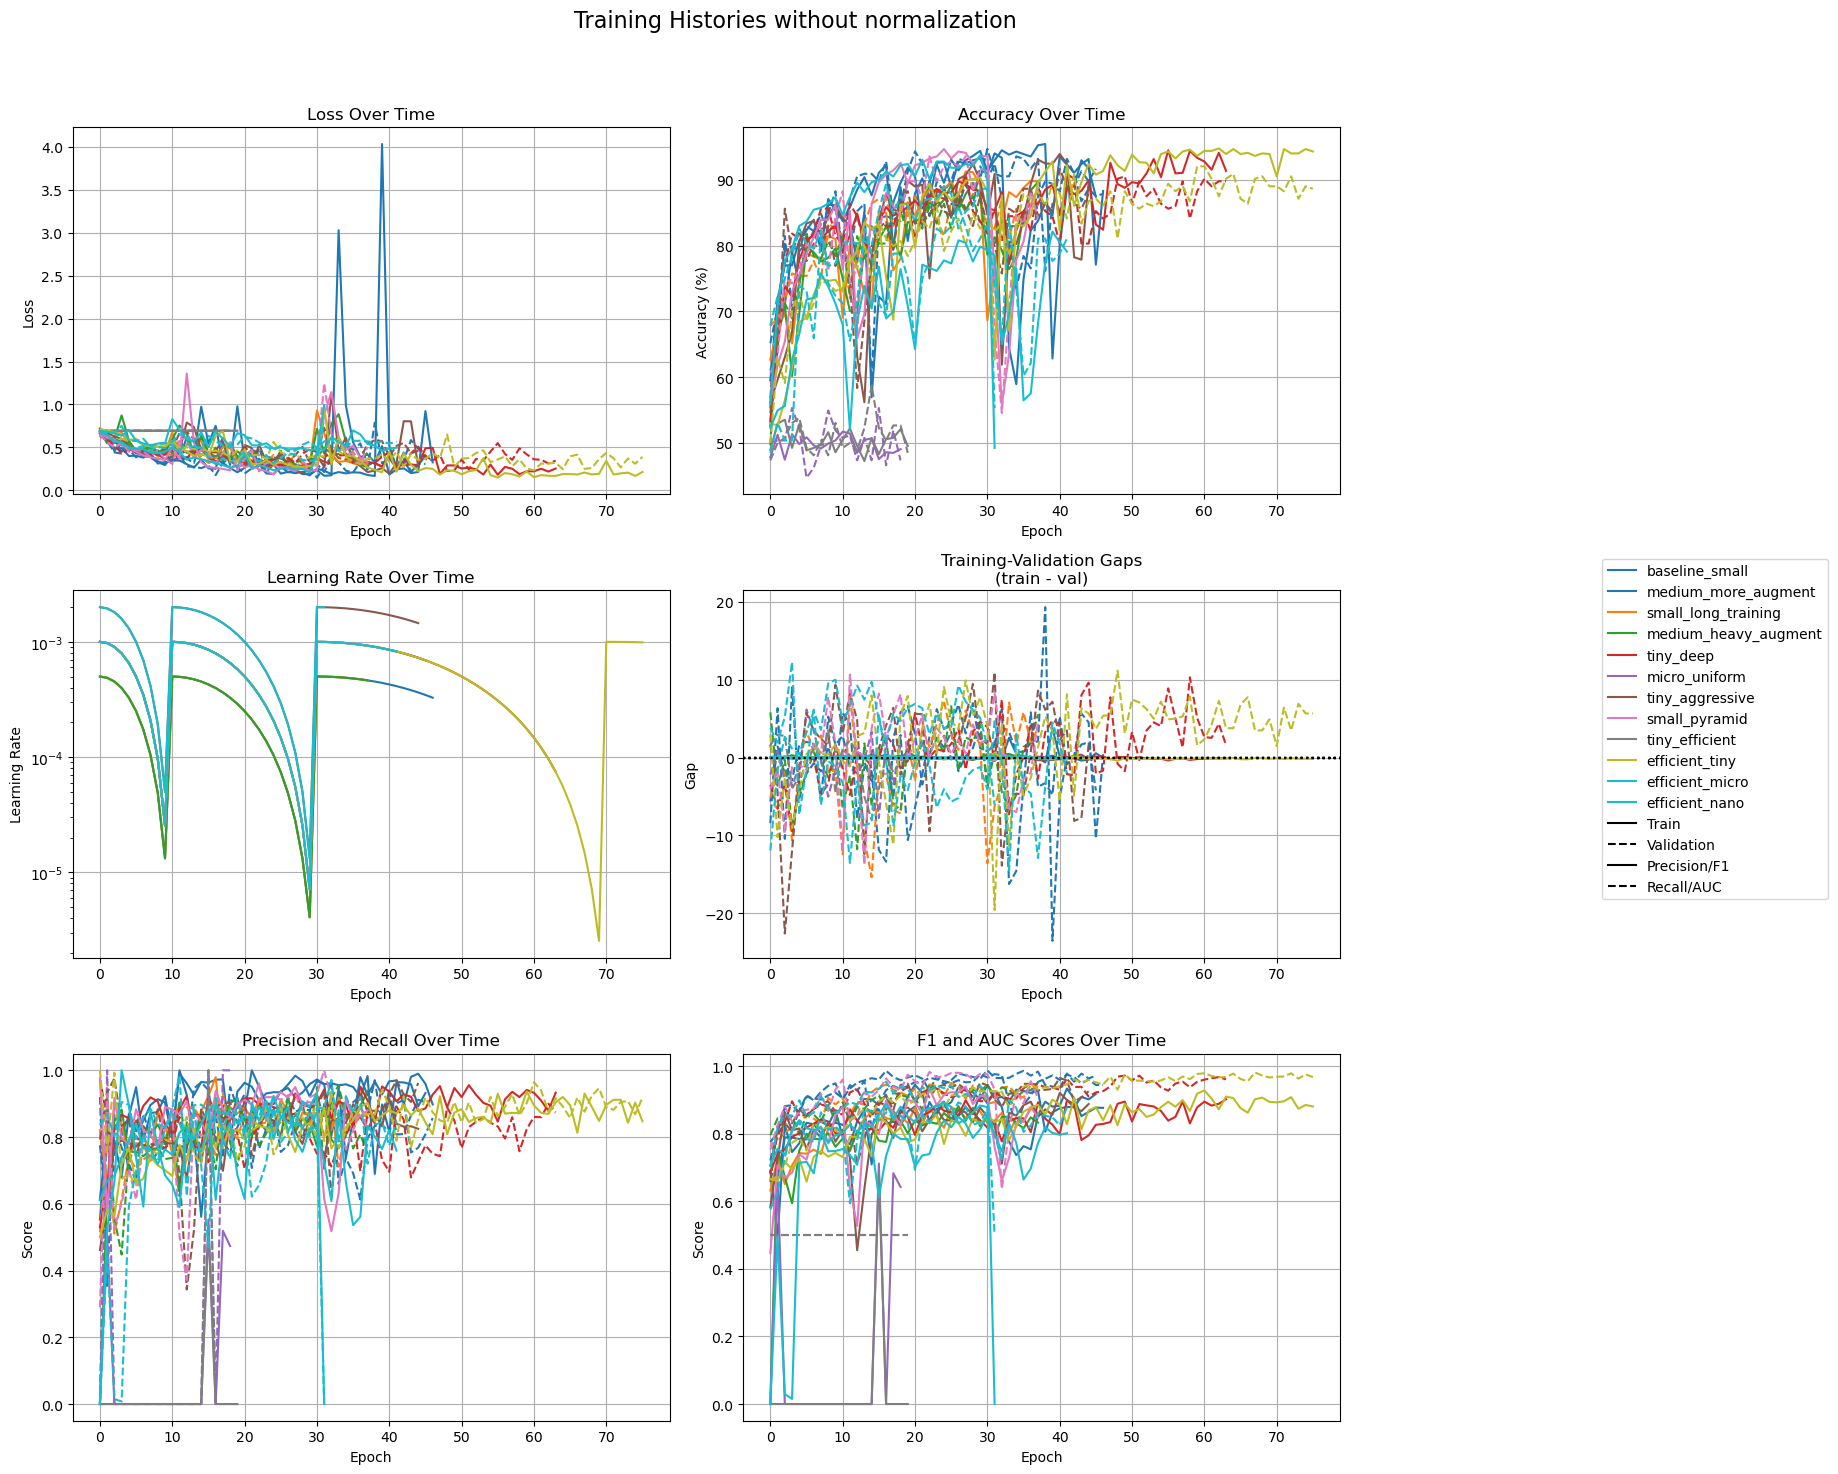

In [ ]:


def load_experiment_histories(experiment_dir):
    # Load the summary file
    with open(os.path.join(experiment_dir, 'final_summary.json'), 'r') as f:
        summary = json.load(f)
    
    histories = {}
    for result in summary['results']:
        if result['status'] == 'success' and 'history_path' in result:
            with open(result['history_path'], 'r') as f:
                histories[result['experiment_name']] = json.load(f)
    
    return histories, summary



def plot_experiment_histories(histories):
    """
    Plot training histories with a single, shared legend.
    """
    # Check what additional metrics are available
    additional_metrics = []
    for history in histories.values():
        additional_metrics.extend([k for k in history.keys() 
                                if k.startswith(('val_precision', 'val_recall', 'val_f1', 'val_auc'))])
    additional_metrics = list(set(additional_metrics))

    # Filter out histories with low val_auc
    # histories = {k: v for k, v in histories.items() if v['val_auc_scores'][-1] > 0.7}
    # print(f"Found {len(histories)} histories with val_auc > 0.7")
    
    # Create figure with correct number of subplots
    n_rows = 3 if additional_metrics else 2
    fig, axes = plt.subplots(n_rows, 2, figsize=(16, 5*n_rows))
    
    # Create color map for different experiments
    colors = plt.cm.tab10(np.linspace(0, 1, len(histories)))
    color_map = {name: colors[i] for i, name in enumerate(histories.keys())}
    
    # Store all line objects for the legend
    legend_lines = []
    legend_labels = []
    
    # Plot basic metrics
    for exp_name, history in histories.items():
        color = color_map[exp_name]
        
        # Loss plot
        train_line, = axes[0,0].plot(history['train_losses'], color=color, linestyle='-')
        val_line, = axes[0,0].plot(history['val_losses'], color=color, linestyle='--')
        
        # Only add to legend once
        if exp_name not in legend_labels:
            legend_lines.append(mlines.Line2D([], [], color=color, label=exp_name))
            legend_labels.append(exp_name)
        
        axes[0,0].set_title('Loss Over Time')
        axes[0,0].set_xlabel('Epoch')
        axes[0,0].set_ylabel('Loss')
        axes[0,0].grid(True)
        
        # Accuracy plot
        axes[0,1].plot(history['train_accuracies'], color=color, linestyle='-')
        axes[0,1].plot(history['val_accuracies'], color=color, linestyle='--')
        axes[0,1].set_title('Accuracy Over Time')
        axes[0,1].set_xlabel('Epoch')
        axes[0,1].set_ylabel('Accuracy (%)')
        axes[0,1].grid(True)
        
        # Learning rate plot
        axes[1,0].plot(history['learning_rates'], color=color)
        axes[1,0].set_title('Learning Rate Over Time')
        axes[1,0].set_xlabel('Epoch')
        axes[1,0].set_ylabel('Learning Rate')
        axes[1,0].set_yscale('log')
        axes[1,0].grid(True)
        
        # Training-validation gaps
        loss_gap = np.array(history['train_losses']) - np.array(history['val_losses'])
        acc_gap = np.array(history['train_accuracies']) - np.array(history['val_accuracies'])
        axes[1,1].plot(loss_gap, color=color, linestyle='-')
        axes[1,1].plot(acc_gap, color=color, linestyle='--')
        axes[1,1].set_title('Training-Validation Gaps\n(train - val)')
        axes[1,1].set_xlabel('Epoch')
        axes[1,1].set_ylabel('Gap')
        axes[1,1].grid(True)
        axes[1,1].axhline(y=0, color='k', linestyle=':')
        
        # Additional metrics plot
        if additional_metrics:
            # Precision/Recall plot
            axes[2,0].plot(history['val_precisions'], color=color, linestyle='-')
            axes[2,0].plot(history['val_recalls'], color=color, linestyle='--')
            axes[2,0].set_title('Precision and Recall Over Time')
            axes[2,0].set_xlabel('Epoch')
            axes[2,0].set_ylabel('Score')
            axes[2,0].grid(True)
            
            # F1 and AUC plot
            axes[2,1].plot(history['val_f1_scores'], color=color, linestyle='-')
            axes[2,1].plot(history['val_auc_scores'], color=color, linestyle='--')
            axes[2,1].set_title('F1 and AUC Scores Over Time')
            axes[2,1].set_xlabel('Epoch')
            axes[2,1].set_ylabel('Score')
            axes[2,1].grid(True)
    
    # Add line style legend items
    train_line = mlines.Line2D([], [], color='black', linestyle='-', label='Train')
    val_line = mlines.Line2D([], [], color='black', linestyle='--', label='Validation')
    legend_lines.append(train_line)
    legend_lines.append(val_line)
    
    # Add special legend items for precision/recall and F1/AUC plots
    if additional_metrics:
        prec_line = mlines.Line2D([], [], color='black', linestyle='-', label='Precision/F1')
        recall_line = mlines.Line2D([], [], color='black', linestyle='--', label='Recall/AUC')
        legend_lines.append(prec_line)
        legend_lines.append(recall_line)
    
    # Create a single legend outside the plots
    plt.figlegend(
        handles=legend_lines,
        loc='center right',
        bbox_to_anchor=(1.15, 0.5),
        fontsize='medium',
        frameon=True
    )
    
    plt.suptitle('Training Histories without normalization', fontsize=16)
    plt.tight_layout(rect=[0, 0, 0.85, 0.95])  # Adjust layout to make room for legend
    plt.show()

from glob import glob
# Load experiment histories
experiment_dirs = glob('experiments_raw/experiment_*')
last_experiment_dir = sorted(experiment_dirs)[-1]

# experiment_dir = 'experiments/experiment_20250313_105140'
histories, summary = load_experiment_histories(last_experiment_dir)

# Plot and save
plot_experiment_histories(
    histories
)

Size of model file promising_models/model_9.onnx: 106.11 KB
Time taken for 100 inferences: 0.01 seconds. FPS: 6970.99
Size of model file promising_models/model_8.onnx: 11.40 KB
Time taken for 100 inferences: 0.02 seconds. FPS: 6061.92
Size of model file promising_models/model_17.onnx: 9.07 KB
Time taken for 100 inferences: 0.01 seconds. FPS: 7382.65
Size of model file promising_models/model_7.onnx: 11.40 KB
Time taken for 100 inferences: 0.01 seconds. FPS: 11347.61
Size of model file promising_models/model_15.onnx: 5.69 KB
Time taken for 100 inferences: 0.01 seconds. FPS: 8177.47
Size of model file promising_models/model_19.onnx: 5.68 KB
Time taken for 100 inferences: 0.01 seconds. FPS: 12687.71
Size of model file promising_models/model_18.onnx: 11.09 KB
Time taken for 100 inferences: 0.01 seconds. FPS: 8980.42
Size of model file promising_models/model_6.onnx: 8.64 KB
Time taken for 100 inferences: 0.01 seconds. FPS: 19918.81
Size of model file promising_models/model_2.onnx: 8.13 KB
Ti

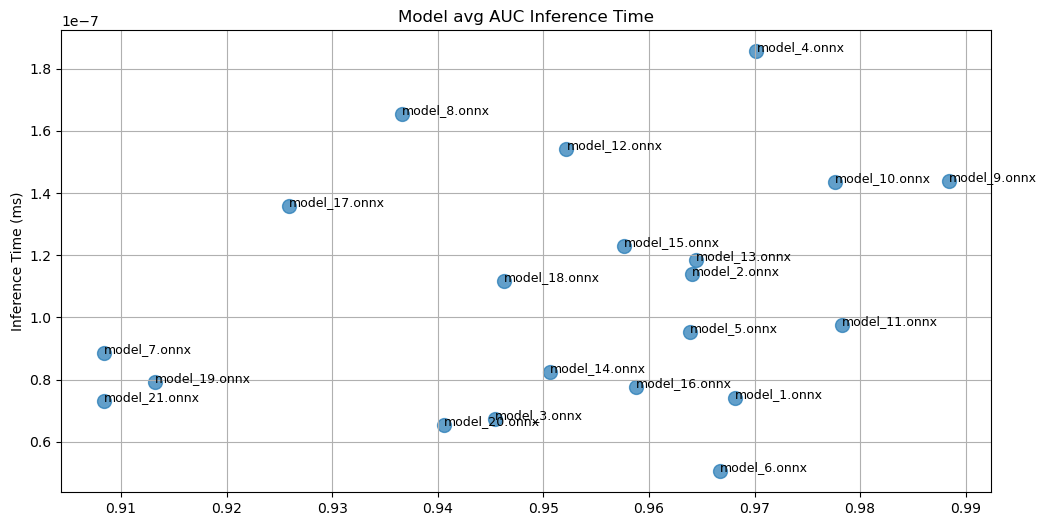

In [23]:
from glob import glob
import os
import onnxruntime as ort
import time
import numpy as np
import matplotlib.pyplot as plt

models = glob('promising_models/model_*.onnx')
# load summary file
summary_file = 'promising_models/selected_models_summary.json'
with open(summary_file, 'r') as f:
    summary = json.load(f)

times_sizes = {}

n = 100
for model_path in models:
    print(f"Size of model file {model_path}: {os.path.getsize(model_path) / 1e3:.2f} KB")
          
    # Load the model
    ort_session = ort.InferenceSession(model_path)

    # Create dummy input for model inference
    input_name = ort_session.get_inputs()[0].name
    input_shape = ort_session.get_inputs()[0].shape
    dummy_input = np.random.random_sample(input_shape).astype(np.float32)

    # Run inference 1000 times and measure time

    
    start_time = time.time()    
    for i in range(n):
        ort_session.run(None, {input_name: dummy_input})

    print(f"Time taken for {n} inferences: {time.time() - start_time:.2f} seconds. FPS: {n / (time.time() - start_time):.2f}")
    times_sizes[model_path] = {
        'time': time.time() - start_time,
        'size': os.path.getsize(model_path) / 1e3,
        'avg_auc': summary[int(os.path.basename(model_path).split('_')[1].split('.')[0]) - 1]['avg_auc']
    }

# Extract the sizes and times
avg_auc = [v['avg_auc'] for v in times_sizes.values()]
times = [v['time']/1000 for v in times_sizes.values()]
names = [os.path.basename(k) for k in times_sizes.keys()]

# Create a scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(avg_auc, np.asarray(times)/n, s=100, alpha=0.7)
plt.ylabel('Inference Time (ms)')
plt.title('Model avg AUC Inference Time')
plt.grid(True)

# Add labels for each point
for i, name in enumerate(names):
    plt.text(avg_auc[i], times[i]/n, name, fontsize=9)

plt.show()
    

In [ ]:
def select_best_model_checkpoint(metrics_tracker, window_size=3):
    """
    Select the best model checkpoint using a sophisticated selection strategy.
    
    Args:
        metrics_tracker: Object containing all training metrics
        window_size: Size of the moving window for smoothing (default: 3)
    
    Returns:
        best_epoch: The epoch number of the best checkpoint
        selection_metrics: Dictionary containing the metrics that led to this selection
    """
    # Convert metrics to numpy arrays for easier manipulation
    val_auc = np.array(metrics_tracker['val_auc_scores'])
    val_loss = np.array(metrics_tracker['val_losses'])
    
    # Calculate moving averages to reduce noise
    def moving_average(x, window):
        return np.convolve(x, np.ones(window), 'valid') / window
    
    if len(val_auc) > window_size:
        smooth_auc = moving_average(val_auc, window_size)
        smooth_loss = moving_average(val_loss, window_size)
        # Adjust indices to account for the window
        offset = window_size - 1
    else:
        smooth_auc = val_auc
        smooth_loss = val_loss
        offset = 0
    
    # Find peaks in AUC (local maxima)
    peak_indices = []
    for i in range(1, len(smooth_auc) - 1):
        if smooth_auc[i] > smooth_auc[i-1] and smooth_auc[i] >= smooth_auc[i+1]:
            peak_indices.append(i)
    
    if not peak_indices:
        # If no peaks found, just use the maximum AUC
        best_idx = np.argmax(smooth_auc)
    else:
        # Among the peaks, prefer later ones if they're close in performance
        # This helps avoid selecting early lucky epochs
        tolerance = 0.001  # 0.1% tolerance
        best_peak_auc = smooth_auc[peak_indices[-1]]
        best_idx = peak_indices[-1]
        
        # Look at earlier peaks
        for idx in reversed(peak_indices[:-1]):
            if smooth_auc[idx] > best_peak_auc + tolerance:
                best_idx = idx
                best_peak_auc = smooth_auc[idx]
    
    # Convert back to original epoch index
    best_epoch = best_idx + offset
    
    # Collect metrics for the selected epoch
    selection_metrics = {
        'epoch': best_epoch,
        'val_auc': metrics_tracker['val_auc_scores'][best_epoch],
        'val_loss': metrics_tracker['val_losses'][best_epoch],
        'val_accuracy': metrics_tracker['val_accuracies'][best_epoch],
        'val_precision': metrics_tracker['val_precisions'][best_epoch],
        'val_recall': metrics_tracker['val_recalls'][best_epoch],
        'val_f1': metrics_tracker['val_f1_scores'][best_epoch],
    }
    
    return best_epoch, selection_metrics

def load_model_from_checkpoint(checkpoint_path, config):
    # Initialize the model with the same configuration
    model = BorderDetector(config)
    
    # Load the checkpoint
    checkpoint = torch.load(checkpoint_path)
    
    # Load the model state dict
    model.load_state_dict(checkpoint['model_state_dict'])
    
    # Set the model to evaluation mode
    model.eval()
    
    return model, checkpoint

results = glob('results_raw/training_output_*')
results = sorted(results)[-48:]

for result in results:
    print(f"Processing {result}")
    # Load the metrics tracker
    with open(os.path.join(result, 'metrics.json'), 'r') as f:
        metrics_tracker = json.load(f)
    print(metrics_tracker.keys())
    
    # Select the best model checkpoint
    best_epoch, selection_metrics = select_best_model_checkpoint(metrics_tracker)
    if selection_metrics['val_auc'] > 0.9:

        print(f"Best epoch: {best_epoch}")
        print("Selection metrics:")
        for k, v in selection_metrics.items():
            print(f"- {k}: {v:.4f}")
        print("Converting model to ONNX")
        # model = BorderDetector()
        checkpoint = torch.load(os.path.join(result, f'checkpoint_epoch_{best_epoch}.pt'))
        print(checkpoint['model_state_dict'].keys())

        

Processing results_raw/training_output_20250316_202752
dict_keys(['train_losses', 'val_losses', 'train_accuracies', 'val_accuracies', 'learning_rates', 'val_precisions', 'val_recalls', 'val_f1_scores', 'val_auc_scores'])
Best epoch: 14
Selection metrics:
- epoch: 14.0000
- val_auc: 0.9919
- val_loss: 0.2050
- val_accuracy: 92.4242
- val_precision: 0.8834
- val_recall: 0.9931
- val_f1: 0.9351
Converting model to ONNX
odict_keys(['conv1.weight', 'conv1.bias', 'conv2.weight', 'conv2.bias', 'conv3.weight', 'conv3.bias', 'fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias'])
Processing results_raw/training_output_20250316_202902
dict_keys(['train_losses', 'val_losses', 'train_accuracies', 'val_accuracies', 'learning_rates', 'val_precisions', 'val_recalls', 'val_f1_scores', 'val_auc_scores'])
Best epoch: 29
Selection metrics:
- epoch: 29.0000
- val_auc: 0.9798
- val_loss: 0.1832
- val_accuracy: 92.4242
- val_precision: 0.9466
- val_recall: 0.9051
- val_f1: 0.9254
Converting model to ONNX
odict

/tmp/ipykernel_38711/1146165178.py:89: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(os.path.join(result, f'checkpoint_epoch_{best_epoch}.pt'))
